## 0. Import librerie e inizializzazione

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import warnings
import random

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
np.random.seed(42)
random.seed(42)
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn.svm._base')

c:\Users\Michele\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 0.1 Import dataset

In [2]:
path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")
df = pd.read_csv(path + "/breast-cancer.csv")
print(f"Dataset caricato. Dimensioni: {df.shape}")
df.head()

Dataset caricato. Dimensioni: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 0.2 Analisi preliminare dataset

In [3]:
print(f"Il dataset contiene {df.shape[0]} righe e {df.shape[1]} colonne.\n")
df.info()
display(df.describe())

missing_values = df.isnull().sum()
print("Valori mancanti per colonna:\n", missing_values[missing_values > 0])

Il dataset contiene 569 righe e 32 colonne.

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Valori mancanti per colonna:
 Series([], dtype: int64)


### 0.3 Analisi target

diagnosis
B    357
M    212
Name: count, dtype: int64
Percentuali:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


C:\Users\Michele\AppData\Local\Temp\ipykernel_13760\3572314673.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='Set2')


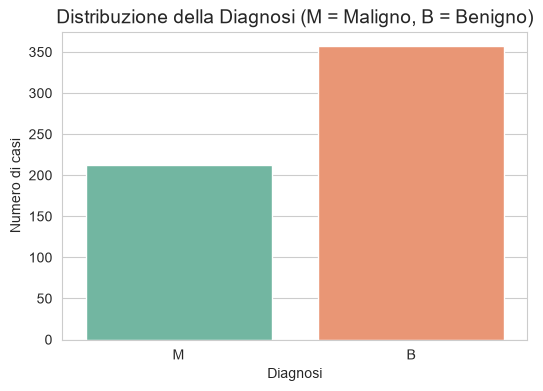

In [4]:
print(df['diagnosis'].value_counts())
print(f"Percentuali:\n{df['diagnosis'].value_counts(normalize=True) * 100}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', palette='Set2')
plt.title('Distribuzione della Diagnosi (M = Maligno, B = Benigno)', fontsize=14)
plt.xlabel('Diagnosi')
plt.ylabel('Numero di casi')
plt.show()

df['diagnosis'] = LabelEncoder().fit_transform(df['diagnosis'])

### 0.4 Analisi features

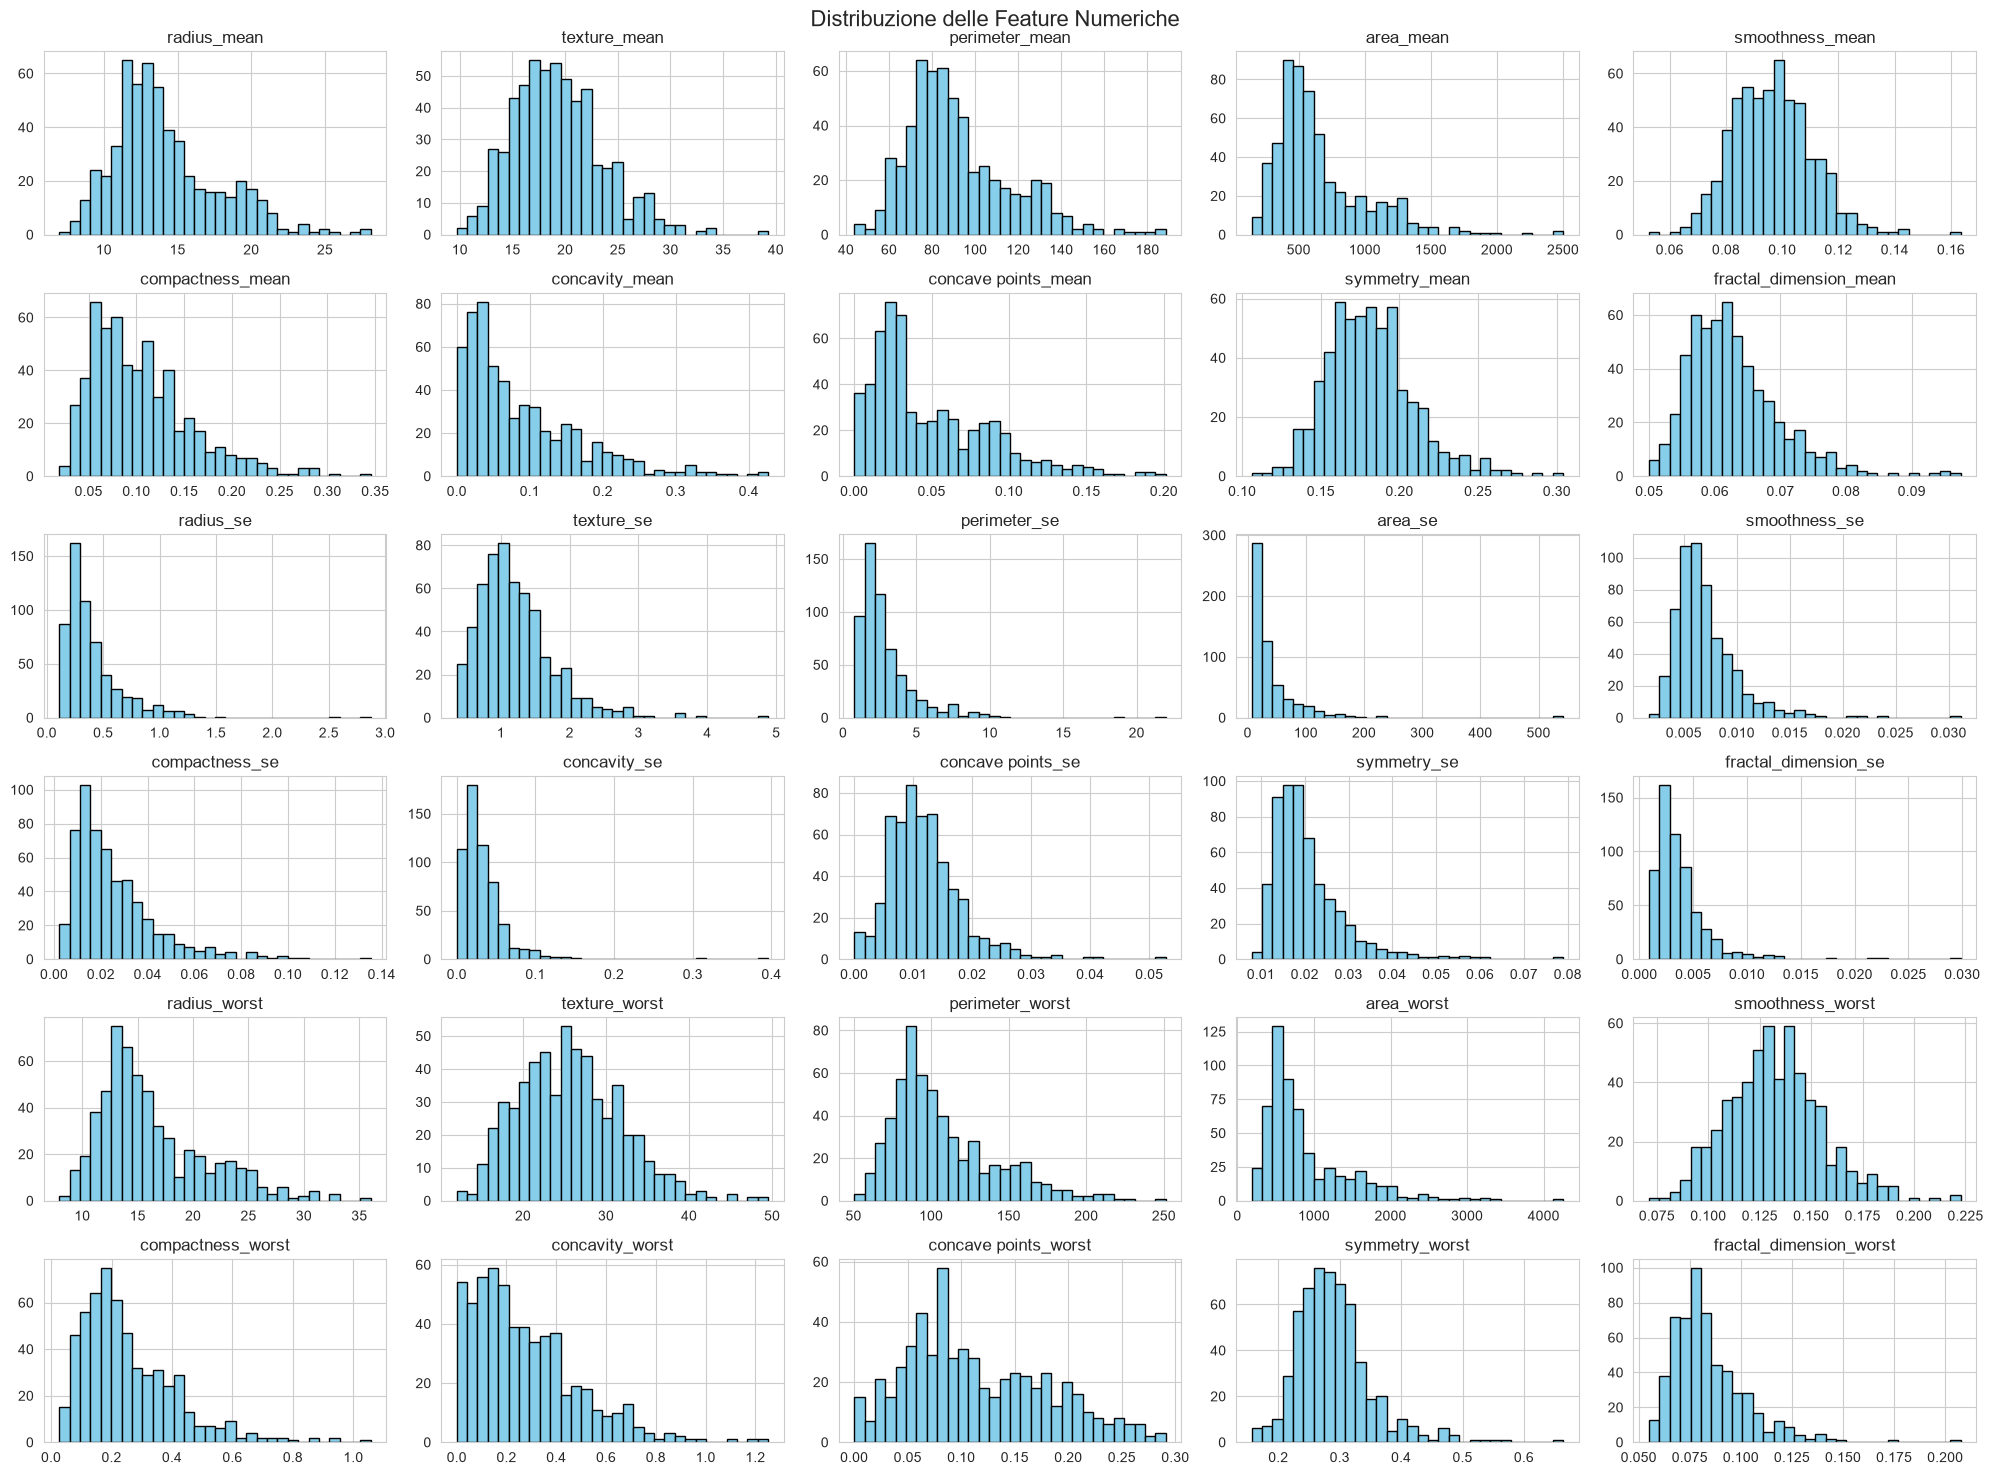

In [5]:
features = df.drop(['id', 'diagnosis'], axis=1)
diagnosis = df['diagnosis']

features.hist(bins=30, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.suptitle('Distribuzione delle Feature Numeriche', fontsize=16)
plt.tight_layout()
plt.show()

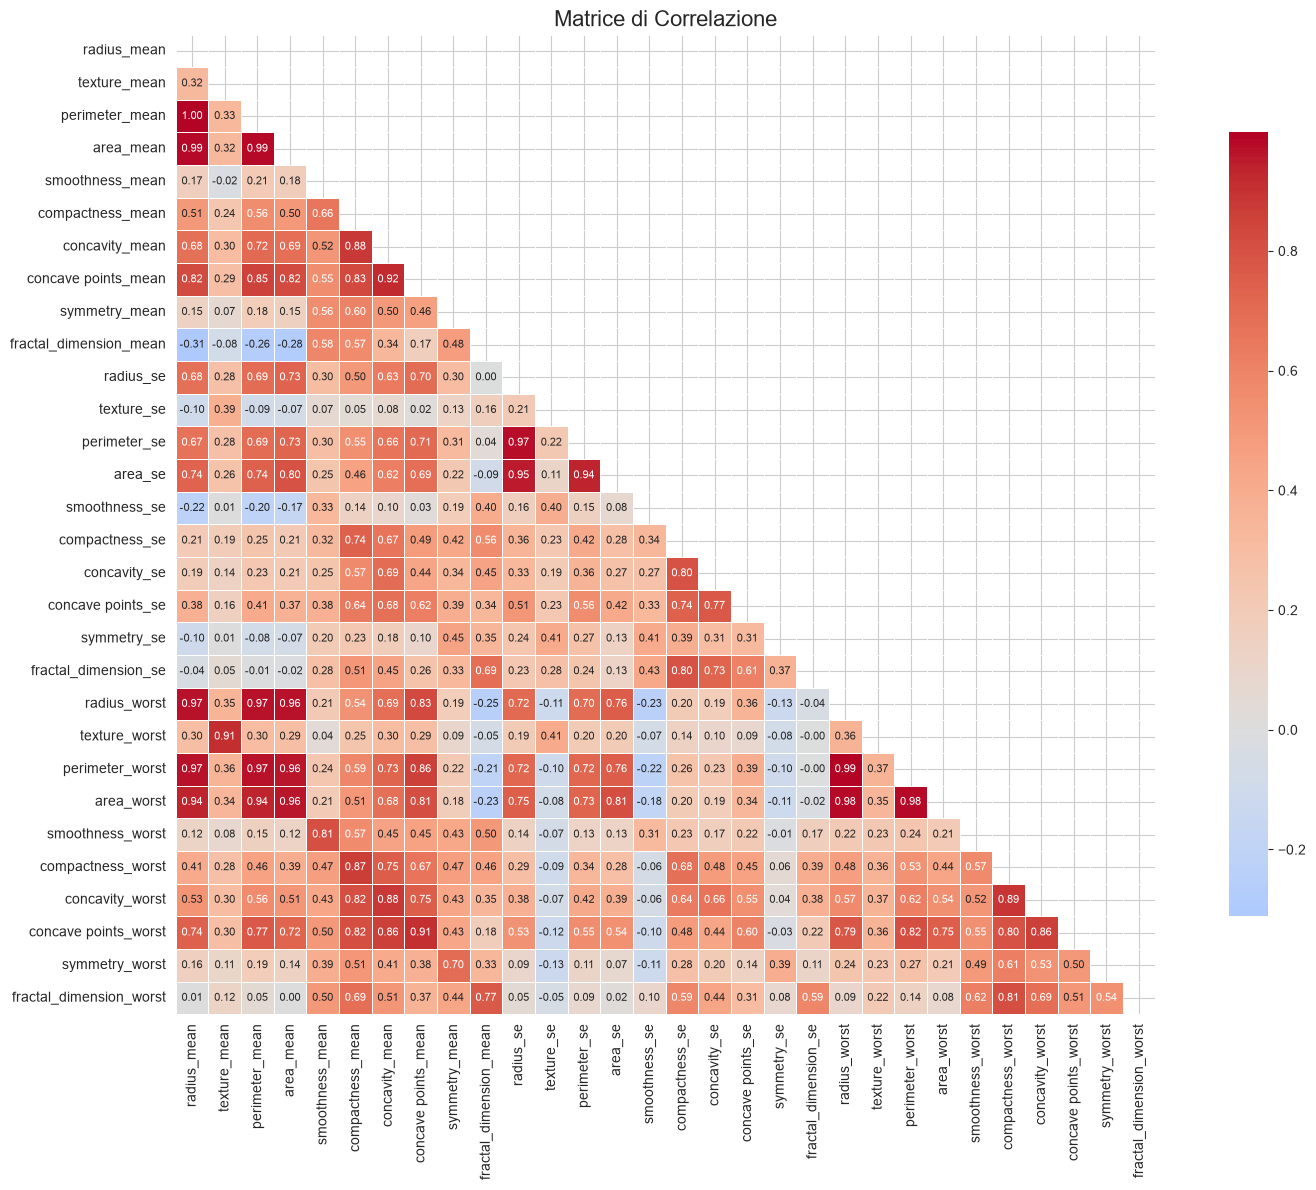

In [6]:
# Matrice di correlazione (solo triangolo inferiore)
correlation_matrix = features.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, annot_kws={'size': 8})
plt.title('Matrice di Correlazione', fontsize=16)
plt.tight_layout()
plt.show()

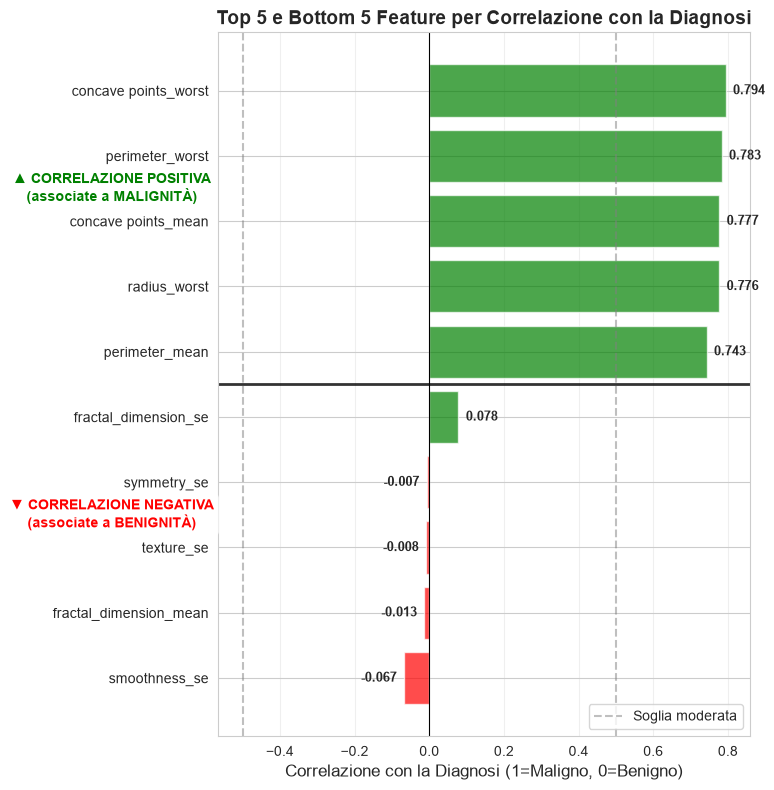

In [7]:
# Top 5 e Bottom 5 feature per correlazione con il target
corr_with_target = (
    pd.concat([features, diagnosis], axis=1)
    .corr()['diagnosis']
    .drop('diagnosis')
    .sort_values()
)
selected_corr = pd.concat([corr_with_target.head(5), corr_with_target.tail(5)])
colors = ['red' if x < 0 else 'green' for x in selected_corr.values]

plt.figure(figsize=(8, 8))
bars = plt.barh(selected_corr.index, selected_corr.values, color=colors, alpha=0.7)
plt.axhline(y=4.5, color='black', linewidth=2, alpha=0.8)
plt.text(-0.85, 2.5, '▼ CORRELAZIONE NEGATIVA\n(associate a BENIGNITÀ)',
         ha='center', va='center', fontsize=10, color='red', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(-0.85, 7.5, '▲ CORRELAZIONE POSITIVA\n(associate a MALIGNITÀ)',
         ha='center', va='center', fontsize=10, color='green', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
for bar, val in zip(bars, selected_corr.values):
    kwargs = dict(y=bar.get_y() + bar.get_height()/2, va='center', fontsize=9, fontweight='bold')
    if val > 0:
        plt.text(bar.get_width() + 0.02, ha='left', s=f'{val:.3f}', **kwargs)
    else:
        plt.text(bar.get_width() - 0.02, ha='right', s=f'{val:.3f}', **kwargs)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Soglia moderata')
plt.axvline(x=-0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Correlazione con la Diagnosi (1=Maligno, 0=Benigno)', fontsize=12)
plt.title('Top 5 e Bottom 5 Feature per Correlazione con la Diagnosi', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 1. Preparazione dataset

In [8]:
X = features
y = diagnosis

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 455, Test size: 114


### 1.1 Funzioni di sporcamento

In [9]:
def add_label_flipping(y, noise_ratio):
    """Flipping casuale dei label (0→1, 1→0)."""
    y_corrupted = y.copy()
    flip_idx = np.random.choice(len(y), int(len(y) * noise_ratio), replace=False)
    y_corrupted.iloc[flip_idx] = 1 - y_corrupted.iloc[flip_idx]
    return y_corrupted


def add_gaussian_noise(X, noise_ratio):
    """Aggiunge rumore gaussiano a una frazione delle feature."""
    X_corrupted = X.copy()
    n_noisy = int(X.shape[1] * noise_ratio)
    for col in np.random.choice(X.columns, n_noisy, replace=False):
        noise = np.random.normal(0, 0.1 * X[col].std(), X.shape[0])
        X_corrupted[col] += noise
    return X_corrupted


def add_outliers(X, outlier_ratio):
    """Inietta outlier estremi (±5*IQR) in tutti le feature,
    su una frazione di campioni proporzionale a outlier_ratio."""
    X_corrupted = X.copy()
    n_outlier_samples = int(X.shape[0] * outlier_ratio)
    for col in X.columns:
        rows = np.random.choice(X.shape[0], n_outlier_samples, replace=False)
        Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
        IQR = Q3 - Q1
        signs = np.where(np.random.random(n_outlier_samples) > 0.5, 1, -1)
        values = np.where(signs > 0, Q3 + 5 * IQR, Q1 - 5 * IQR)
        X_corrupted.iloc[rows, X_corrupted.columns.get_loc(col)] = values
    return X_corrupted


def add_missing_features(X, missing_ratio):
    """Imposta a 0 una percentuale casuale di celle (emula valori mancanti)."""
    X_corrupted = X.copy()
    n_missing = int(X.shape[0] * X.shape[1] * missing_ratio)
    rows = np.random.choice(X.shape[0], n_missing, replace=True)
    cols = np.random.choice(X.shape[1], n_missing, replace=True)
    for r, c in zip(rows, cols):
        X_corrupted.iloc[r, c] = 0
    return X_corrupted


# Dispatcher
CORRUPTION_FNS = {
    'label_flipping':   lambda X, y, r: (X.copy(),                  add_label_flipping(y, r)),
    'gaussian_noise':   lambda X, y, r: (add_gaussian_noise(X, r),  y.copy()),
    'outliers':         lambda X, y, r: (add_outliers(X, r),         y.copy()),
    'missing_features': lambda X, y, r: (add_missing_features(X, r), y.copy()),
}

### 1.2 Creazione e standardizzazione dataset corrotti

In [10]:
CORRUPTION_LEVELS = [0.10, 0.20, 0.30, 0.40, 0.50]
CORRUPTION_TYPES  = list(CORRUPTION_FNS.keys())

def standardize(X_tr, X_te):
    """Fit scaler su train, trasforma entrambi; restituisce DataFrame."""
    scaler = StandardScaler()
    def to_df(arr, ref): return pd.DataFrame(arr, columns=ref.columns, index=ref.index)
    return to_df(scaler.fit_transform(X_tr), X_tr), to_df(scaler.transform(X_te), X_te)


# Costruisce l'intera struttura: standardized_datasets[corr_type][level]
# Il livello 0 è il dataset pulito (condiviso come baseline)
X_tr_base, X_te_base = standardize(X_train, X_test)

standardized_datasets = {}

for corr_type in CORRUPTION_TYPES:
    standardized_datasets[corr_type] = {}

    # Baseline (level 0) uguale per tutti i tipi
    standardized_datasets[corr_type][0] = {
        'X_train': X_tr_base, 'X_test': X_te_base,
        'y_train': y_train,   'y_test': y_test
    }

    for level in CORRUPTION_LEVELS:
        X_corr, y_corr = CORRUPTION_FNS[corr_type](X_train, y_train, level)
        X_tr_s, X_te_s = standardize(X_corr, X_test)
        standardized_datasets[corr_type][level] = {
            'X_train': X_tr_s, 'X_test': X_te_s,
            'y_train': y_corr, 'y_test': y_test
        }

print("Tutti i dataset creati e standardizzati.")

Tutti i dataset creati e standardizzati.


## 2. Addestramento e valutazione

In [11]:
MODELS = {
    'SVM':          SVC(kernel='linear', C=1.0, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'MLP':          MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                  alpha=0.0001, early_stopping=True,
                                  validation_fraction=0.1, max_iter=200,
                                  random_state=42),
}


def evaluate(model, X_train, y_train, X_test, y_test):
    """Addestra il modello e restituisce un dict con le metriche."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='binary', zero_division=0),
        'recall':    recall_score(y_test, y_pred,    average='binary', zero_division=0),
        'f1_score':  f1_score(y_test, y_pred,        average='binary', zero_division=0),
    }


# Loop unico su tutti i modelli × tipi di corruzione × livelli
records = []

for model_name, model in MODELS.items():
    for corr_type in CORRUPTION_TYPES:
        for level, data in standardized_datasets[corr_type].items():
            metrics = evaluate(
                model,
                data['X_train'], data['y_train'],
                data['X_test'],  data['y_test']
            )
            records.append({'model': model_name, 'corruption_type': corr_type,
                            'corruption_level': level, **metrics})
            print(f"{model_name:15s} | {corr_type:20s} | {level:.0%} | "                  f"Acc={metrics['accuracy']:.4f}  F1={metrics['f1_score']:.4f}")

results_df = pd.DataFrame(records)
print("\nAddestramento completato.")

SVM             | label_flipping       | 0% | Acc=0.9649  F1=0.9500
SVM             | label_flipping       | 10% | Acc=0.9561  F1=0.9398
SVM             | label_flipping       | 20% | Acc=0.9298  F1=0.9000
SVM             | label_flipping       | 30% | Acc=0.9035  F1=0.8493
SVM             | label_flipping       | 40% | Acc=0.6579  F1=0.6486
SVM             | label_flipping       | 50% | Acc=0.6228  F1=0.6195
SVM             | gaussian_noise       | 0% | Acc=0.9649  F1=0.9500
SVM             | gaussian_noise       | 10% | Acc=0.9561  F1=0.9367
SVM             | gaussian_noise       | 20% | Acc=0.9649  F1=0.9500
SVM             | gaussian_noise       | 30% | Acc=0.9649  F1=0.9500
SVM             | gaussian_noise       | 40% | Acc=0.9649  F1=0.9512
SVM             | gaussian_noise       | 50% | Acc=0.9561  F1=0.9383
SVM             | outliers             | 0% | Acc=0.9649  F1=0.9500
SVM             | outliers             | 10% | Acc=0.9298  F1=0.8947
SVM             | outliers           

## 3. Visualizzazione risultati

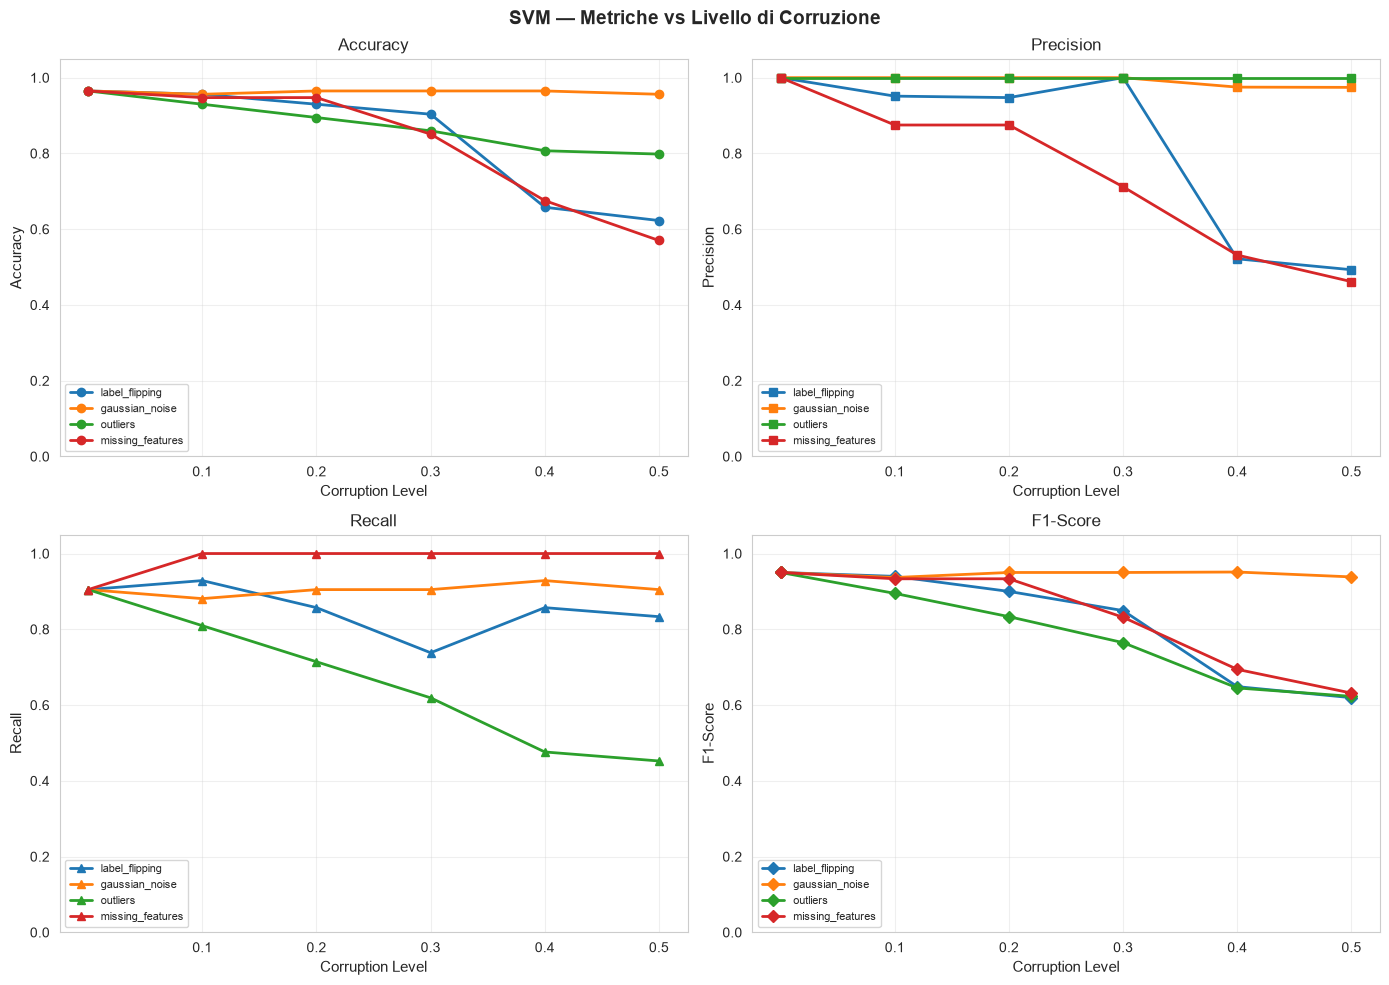

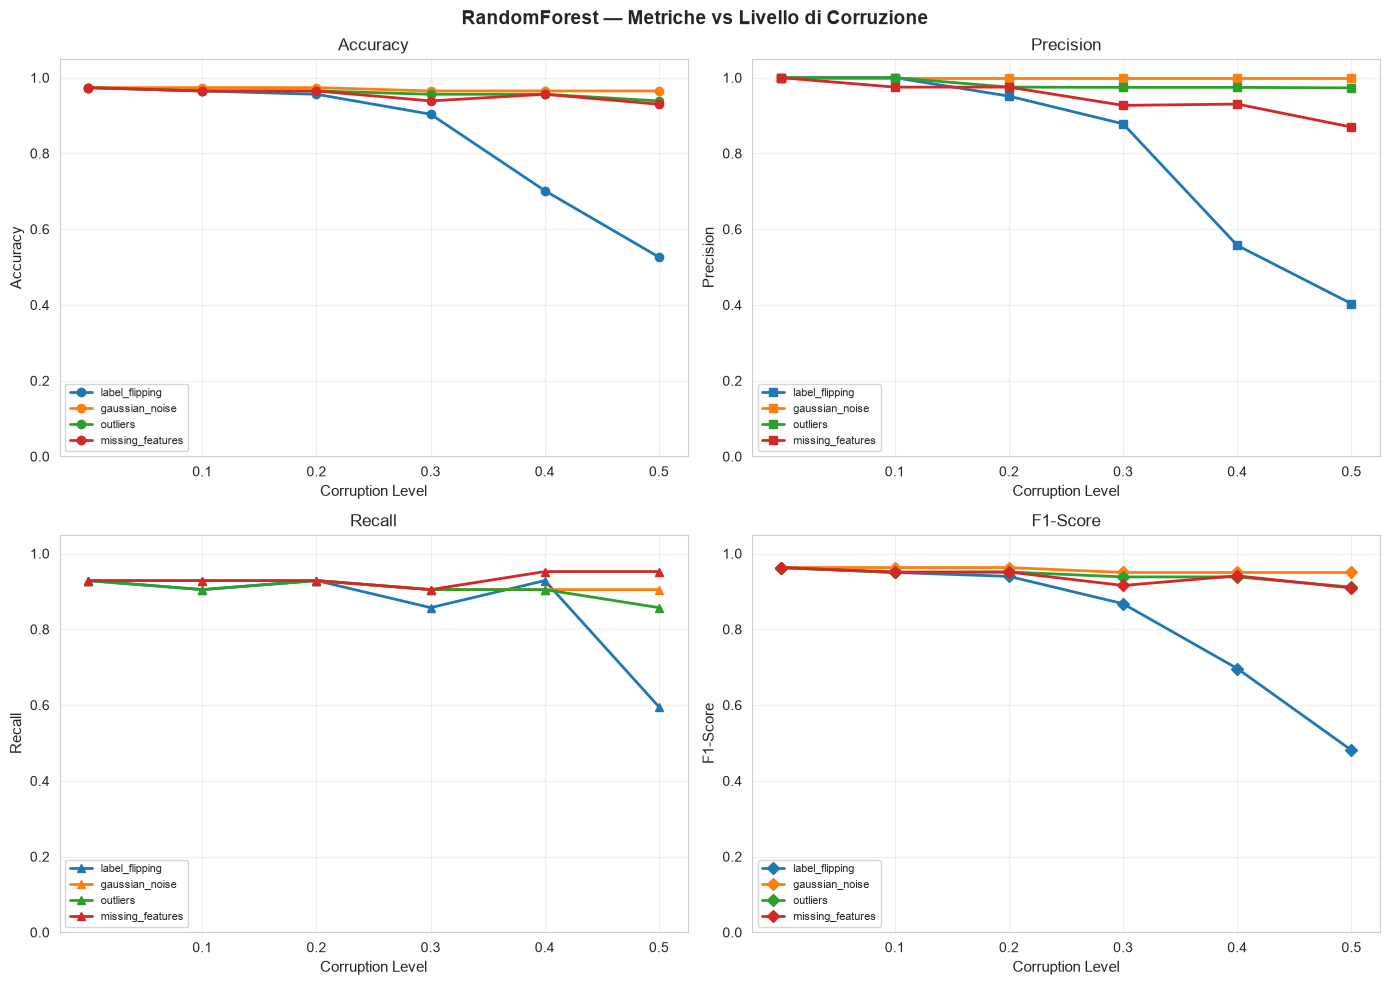

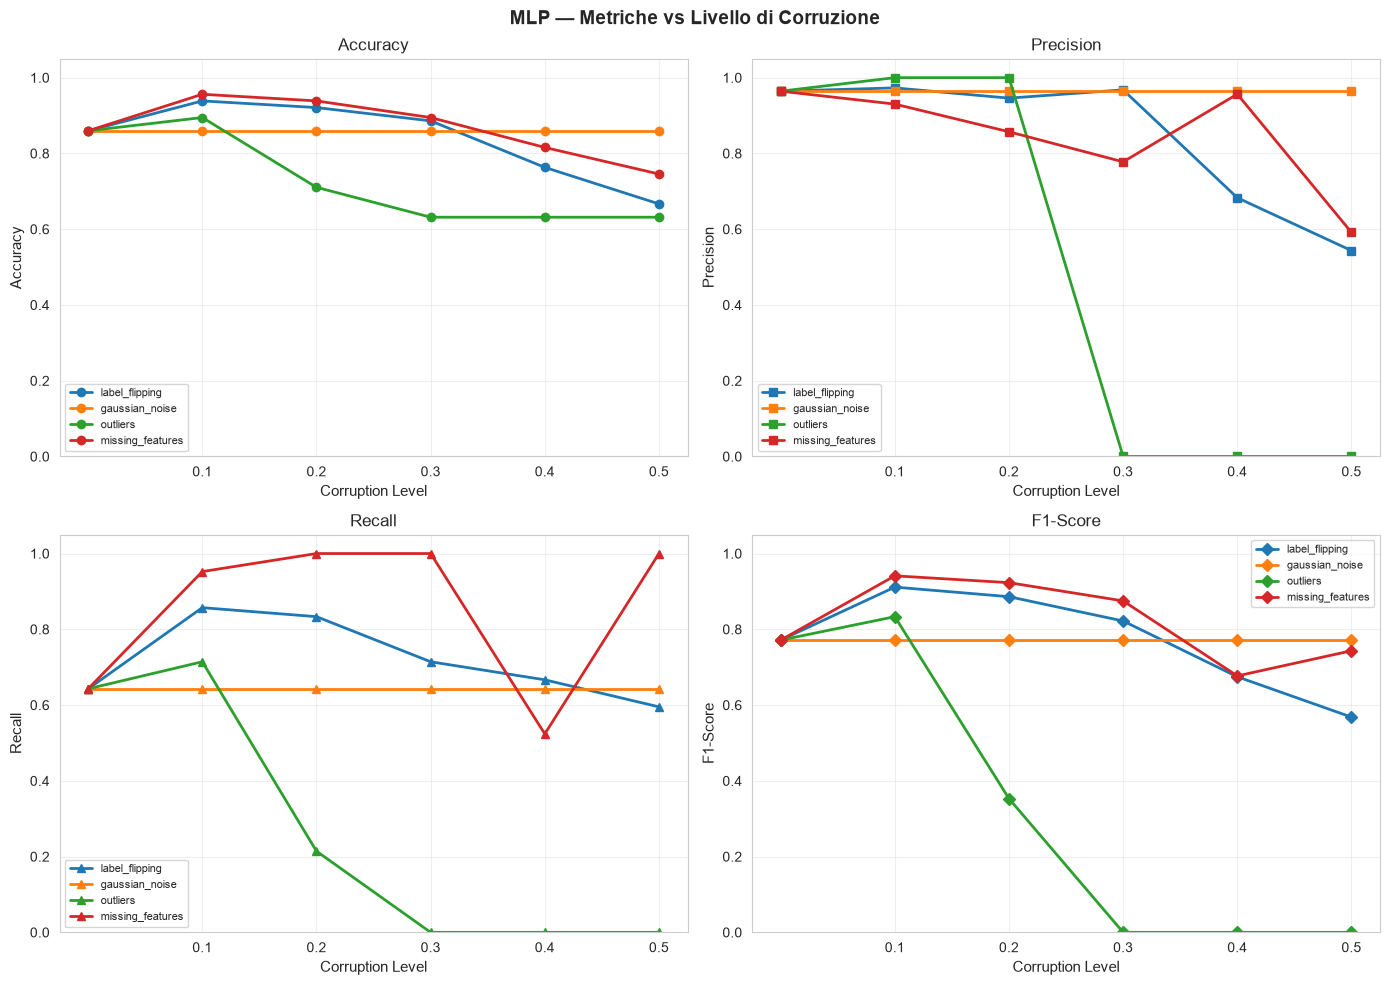

In [12]:
METRICS = ['accuracy', 'precision', 'recall', 'f1_score']
METRIC_LABELS = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
MARKERS = ['o', 's', '^', 'D']


def plot_metrics(df, model_name):
    """Grafici 2x2 delle metriche per un singolo modello."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{model_name} — Metriche vs Livello di Corruzione', fontsize=14, fontweight='bold')

    for ax, metric, label, marker in zip(axes.flat, METRICS, METRIC_LABELS, MARKERS):
        for corr_type in df['corruption_type'].unique():
            subset = df[(df['model'] == model_name) & (df['corruption_type'] == corr_type)]
            ax.plot(subset['corruption_level'], subset[metric],
                    marker=marker, label=corr_type, linewidth=2, markersize=6)
        ax.set_xlabel('Corruption Level', fontsize=11)
        ax.set_ylabel(label, fontsize=11)
        ax.set_title(label, fontsize=12)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(CORRUPTION_LEVELS)
        ax.set_ylim([0, 1.05])

    plt.tight_layout()
    plt.show()


for model_name in MODELS:
    plot_metrics(results_df, model_name)

## 4. Confronto tra modelli

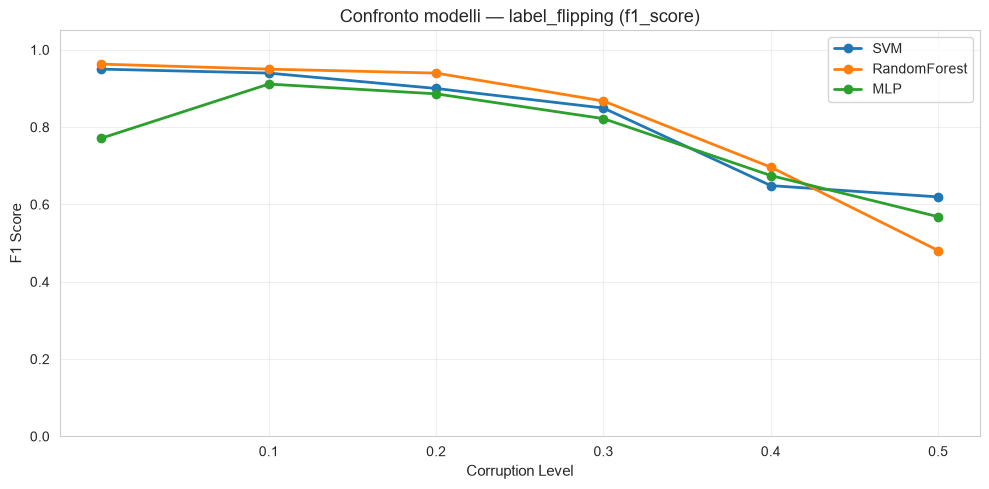

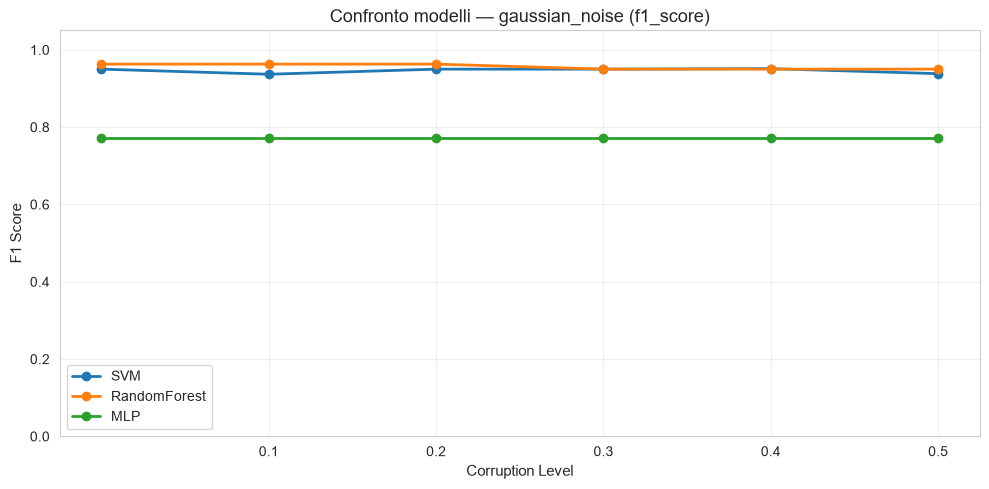

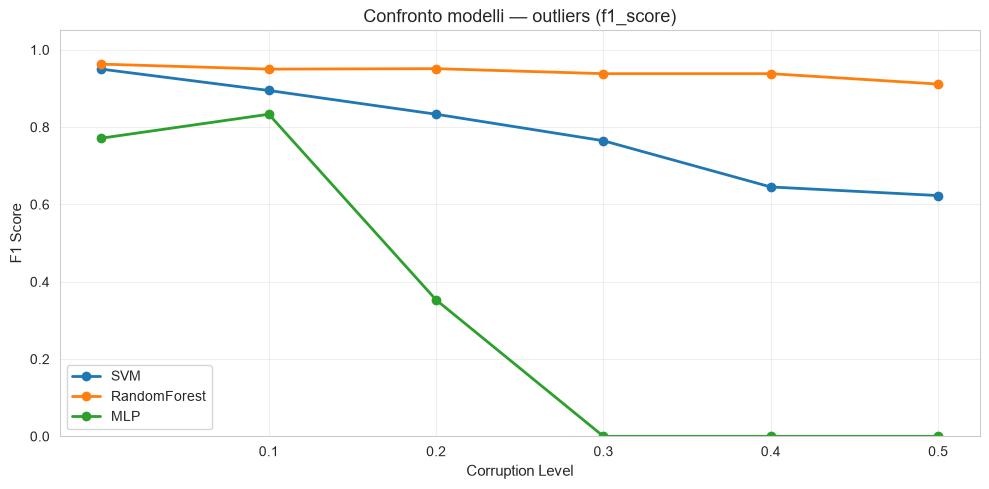

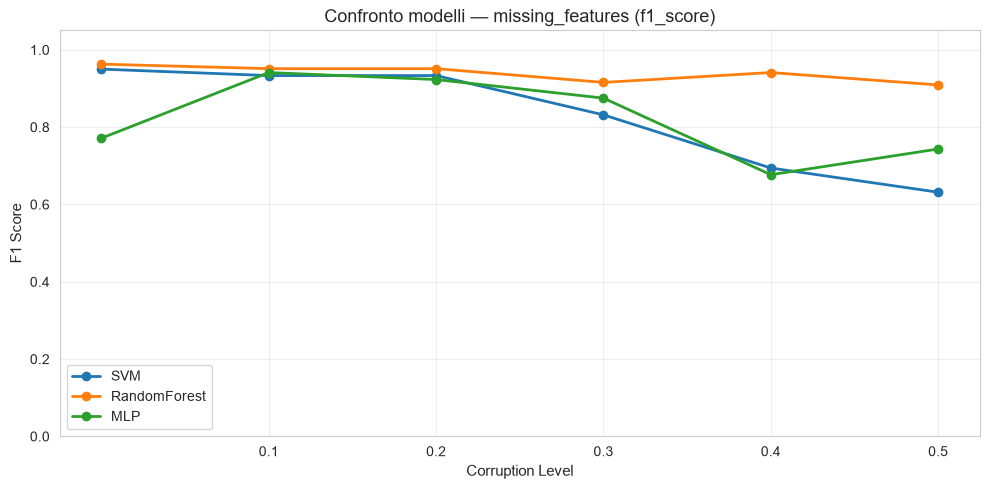

In [13]:
def plot_model_comparison(df, corr_type, metric='f1_score'):
    """Confronto tra modelli per un tipo di corruzione e una metrica."""
    plt.figure(figsize=(10, 5))
    subset = df[df['corruption_type'] == corr_type]
    for model_name in MODELS:
        s = subset[subset['model'] == model_name]
        plt.plot(s['corruption_level'], s[metric],
                 marker='o', label=model_name, linewidth=2, markersize=6)
    plt.xlabel('Corruption Level', fontsize=11)
    plt.ylabel(metric.replace('_', ' ').title(), fontsize=11)
    plt.title(f'Confronto modelli — {corr_type} ({metric})', fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(CORRUPTION_LEVELS)
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.show()


for corr_type in CORRUPTION_TYPES:
    plot_model_comparison(results_df, corr_type, metric='f1_score')